# Ноутбук 3 - Базовый эксперимент | RoBERTa + One-Hot

| | |
|---|---|
| **Модель** | `roberta-base` |
| **Разметка** | one-hot (бинарная multi-label) |
| **Лосс** | BCEWithLogitsLoss |


## Импорты и версии библиотек

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import polars as pl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, hamming_loss, accuracy_score
from IPython.display import display

In [2]:
packages = ['NumPy', 'Pandas', 'Polars', 'Matplotlib', 'Seaborn', 'Torch', 'Transformers']
package_objects = [np, pd, pl, mpl, sns, torch, __import__('transformers')]
versions = [obj.__version__ for obj in package_objects]

columns_order = ['№', 'Библиотека', 'Версия']
df_pkgs = (
    pl.DataFrame({columns_order[1]: packages, columns_order[2]: versions})
    .with_columns(pl.arange(1, pl.lit(len(packages)) + 1).alias(columns_order[0]))
    .select(columns_order)
)
display(df_pkgs)

№,Библиотека,Версия
i64,str,str
1,"""NumPy""","""2.0.2"""
2,"""Pandas""","""2.2.2"""
3,"""Polars""","""1.35.2"""
4,"""Matplotlib""","""3.10.0"""
5,"""Seaborn""","""0.13.2"""
6,"""Torch""","""2.10.0+cu128"""
7,"""Transformers""","""5.0.0"""


In [3]:
CONFIG = {
    'model_name': 'roberta-base',
    'max_length': 64,
    'batch_size': 32,
    'num_epochs': 5,
    'learning_rate': 2e-5,
    'threshold': 0.5,
    'num_labels': 28,
    'data_dir': 'data',
    'results_dir': 'results',
}

os.makedirs(CONFIG['results_dir'], exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
EMOTIONS = [
    "admiration", "amusement", "approval", "caring", "desire",
    "excitement", "gratitude", "joy", "love", "optimism",
    "pride", "relief", "anger", "annoyance", "disappointment",
    "disapproval", "disgust", "embarrassment", "fear", "grief",
    "nervousness", "remorse", "sadness", "confusion", "curiosity",
    "realization", "surprise", "neutral",
]
NUM_EMOTIONS = len(EMOTIONS)
print(f'Эмоций: {NUM_EMOTIONS}')

Эмоций: 28


## Загрузка данных

In [6]:
def load_or_create_csv():
    from datasets import load_dataset
    dataset = load_dataset('go_emotions', 'simplified')

    EMOTIONS_HF = [
        'admiration','amusement','anger','annoyance','approval',
        'caring','confusion','curiosity','desire','disappointment',
        'disapproval','disgust','embarrassment','excitement','fear',
        'gratitude','grief','joy','love','nervousness','optimism',
        'pride','realization','relief','remorse','sadness','surprise','neutral'
    ]

    def hf_to_df(split):
        records = []
        for item in split:
            row = {'id': item['id'], 'text': item['text']}
            vec = {e: 0 for e in EMOTIONS}
            for idx in item['labels']:
                emo = EMOTIONS_HF[idx]
                if emo in vec:
                    vec[emo] = 1
            row.update(vec)
            records.append(row)
        return pd.DataFrame(records)

    os.makedirs(CONFIG['data_dir'], exist_ok=True)
    train_df = hf_to_df(dataset['train'])
    val_df = hf_to_df(dataset['validation'])
    test_df = hf_to_df(dataset['test'])
    train_df.to_csv(os.path.join(CONFIG['data_dir'], 'train.csv'), index=False)
    val_df.to_csv(os.path.join(CONFIG['data_dir'], 'val.csv'), index=False)
    test_df.to_csv(os.path.join(CONFIG['data_dir'], 'test.csv'), index=False)
    print('Сохранено в data/')
    return train_df, val_df, test_df

train_df, val_df, test_df = load_or_create_csv()
print(f'train:{train_df.shape}')
print(f'val: {val_df.shape}')
print(f'test: {test_df.shape}')

Сохранено в data/
train:(43410, 30)
val: (5426, 30)
test: (5427, 30)


In [7]:
row = train_df.iloc[0]
active = [e for e in EMOTIONS if row[e] == 1]
print(f'Пример: {row["text"]}')
print(f'Эмоции: {active}')
print()
label_counts = train_df[EMOTIONS].sum(axis=1)
print('Меток на пример:')
print(label_counts.value_counts().sort_index().to_string())

Пример: My favourite food is anything I didn't have to cook myself.
Эмоции: ['neutral']

Меток на пример:
1    36308
2     6541
3      532
4       28
5        1


In [8]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print(f'Токенизатор: {CONFIG["model_name"]}')

print(f'max_length из конфига: {CONFIG["max_length"]}')

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Токенизатор: roberta-base
max_length из конфига: 64


## Dataset и DataLoader

In [9]:
class EmotionDataset(Dataset):
    # Dataset для multi-label классификации эмоций
    # Токенизирует текст, возвращает input_ids, attention_mask, labels
    def __init__(self, df, tokenizer, max_length, emotions):
        self.texts = df['text'].tolist()
        self.labels = df[emotions].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }

In [10]:
train_dataset = EmotionDataset(train_df, tokenizer, CONFIG['max_length'], EMOTIONS)
val_dataset = EmotionDataset(val_df, tokenizer, CONFIG['max_length'], EMOTIONS)
test_dataset = EmotionDataset(test_df, tokenizer, CONFIG['max_length'], EMOTIONS)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

print(f'train batches: {len(train_loader)}')
print(f'val batches: {len(val_loader)}')
print(f'test batches: {len(test_loader)}')

batch = next(iter(train_loader))
print(f'input_ids: {batch["input_ids"].shape}')
print(f'attention_mask: {batch["attention_mask"].shape}')
print(f'labels: {batch["labels"].shape}')

train batches: 1357
val batches: 170
test batches: 170
input_ids: torch.Size([32, 64])
attention_mask: torch.Size([32, 64])
labels: torch.Size([32, 28])


## Модель

Архитектура: RoBERTa энкодер + линейный классификатор.  
Берем `[CLS]` токен из последнего слоя -> Dropout -> Linear(768, 28).  
Возвращаем logits - sigmoid применяется внутри BCEWithLogitsLoss

In [11]:
class RoBERTaForEmotions(nn.Module):
    # RoBERTa-base с линейным классификатором для multi-label задачи
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits

In [12]:
model = RoBERTaForEmotions(CONFIG['model_name'], CONFIG['num_labels'])
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров: {total_params:,}')
print(f'Обучаемых: {trainable_params:,}')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Всего параметров: 124,667,164
Обучаемых: 124,667,164


In [13]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=0.01,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
)

print('Лосс: BCEWithLogitsLoss')
print(f'Оптимизатор: AdamW, lr={CONFIG["learning_rate"]}')
print(f'Шедулер: CosineAnnealingLR, T_max={CONFIG["num_epochs"]}')

Лосс: BCEWithLogitsLoss
Оптимизатор: AdamW, lr=2e-05
Шедулер: CosineAnnealingLR, T_max=5


## Обучение

In [14]:
def compute_metrics(labels, preds, threshold=0.5):
    binary_preds = (preds >= threshold).astype(int)
    return {
        'micro_f1': round(f1_score(labels, binary_preds, average='micro', zero_division=0), 4),
        'macro_f1': round(f1_score(labels, binary_preds, average='macro', zero_division=0), 4),
        'hamming': round(hamming_loss(labels, binary_preds), 4),
        'subset_acc': round(accuracy_score(labels, binary_preds), 4),
    }

In [15]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    pbar = tqdm(loader, desc='train', leave=False)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='eval', leave=False)
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    metrics = compute_metrics(all_labels, all_preds, threshold)
    metrics['loss'] = round(total_loss / len(loader), 4)
    return metrics, all_labels, all_preds

In [16]:
history = {
    'train_loss': [],
    'val_loss': [],
    'val_micro_f1': [],
    'val_macro_f1': [],
}

best_macro_f1 = 0
best_model_path = os.path.join(CONFIG['results_dir'], 'onehot_bce_best.pt')

print('Начало обучения')
print(f'Эпох: {CONFIG["num_epochs"]}  |  Батч: {CONFIG["batch_size"]}  |  lr: {CONFIG["learning_rate"]}')
print('\n')

for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_micro_f1'].append(val_metrics['micro_f1'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])

    if val_metrics['macro_f1'] > best_macro_f1:
        best_macro_f1 = val_metrics['macro_f1']
        torch.save(model.state_dict(), best_model_path)
        flag = ' <- best'
    else:
        flag = ''

    print(
        f'Epoch {epoch}/{CONFIG["num_epochs"]} | '
        f'train_loss: {train_loss:.4f} | '
        f'val_loss: {val_metrics["loss"]:.4f} | '
        f'micro_f1: {val_metrics["micro_f1"]:.4f} | '
        f'macro_f1: {val_metrics["macro_f1"]:.4f}'
        f'{flag}'
    )

print('\n')
print(f'Лучший Macro-F1 на val: {best_macro_f1:.4f}')

Начало обучения
Эпох: 5  |  Батч: 32  |  lr: 2e-05




train:   0%|          | 0/1357 [00:00<?, ?it/s]

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 1/5 | train_loss: 0.1157 | val_loss: 0.0874 | micro_f1: 0.5664 | macro_f1: 0.3415 <- best


train:   0%|          | 0/1357 [00:00<?, ?it/s]

...

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 4/5 | train_loss: 0.0664 | val_loss: 0.0841 | micro_f1: 0.5900 | macro_f1: 0.4883 <- best


train:   0%|          | 0/1357 [00:00<?, ?it/s]

eval:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 5/5 | train_loss: 0.0610 | val_loss: 0.0854 | micro_f1: 0.5878 | macro_f1: 0.4924 <- best


Лучший Macro-F1 на val: 0.4924


## Оценка на тесте

In [17]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print(f'Загружена лучшая модель: {best_model_path}')

test_metrics, test_labels, test_preds = eval_epoch(model, test_loader, criterion, DEVICE)

print()
print('РЕЗУЛЬТАТЫ НА TEST')
print(f'Micro-F1: {test_metrics["micro_f1"]}')
print(f'Macro-F1: {test_metrics["macro_f1"]}')
print(f'Hamming Loss: {test_metrics["hamming"]}')
print(f'Subset Acc: {test_metrics["subset_acc"]}')


Загружена лучшая модель: results/onehot_bce_best.pt


eval:   0%|          | 0/170 [00:00<?, ?it/s]


РЕЗУЛЬТАТЫ НА TEST
Micro-F1: 0.5994
Macro-F1: 0.5092
Hamming Loss: 0.0303
Subset Acc: 0.4828


In [18]:
binary_preds = (test_preds >= CONFIG['threshold']).astype(int)

per_class_f1 = f1_score(test_labels, binary_preds, average=None, zero_division=0)
df_per_class = pd.DataFrame({
    'emotion': EMOTIONS,
    'f1': per_class_f1.round(4),
    'support': test_labels.sum(axis=0).astype(int),
}).sort_values('f1', ascending=False).reset_index(drop=True)

print('Per-class F1 на test:')
display(df_per_class)

df_per_class.to_csv(
    os.path.join(CONFIG['results_dir'], 'onehot_bce_per_class_f1.csv'),
    index=False
)
print('Сохранено: results/onehot_bce_per_class_f1.csv')

Per-class F1 на test:


,emotion,f1,support
0,gratitude,0.9233,352
1,amusement,0.8366,264
2,love,0.8277,238
3,admiration,0.7198,504
4,fear,0.6928,78
5,joy,0.6472,161
6,remorse,0.6452,56
7,neutral,0.6268,1787
8,sadness,0.5733,156
9,optimism,0.5723,186


Сохранено: results/onehot_bce_per_class_f1.csv


## Визуализация

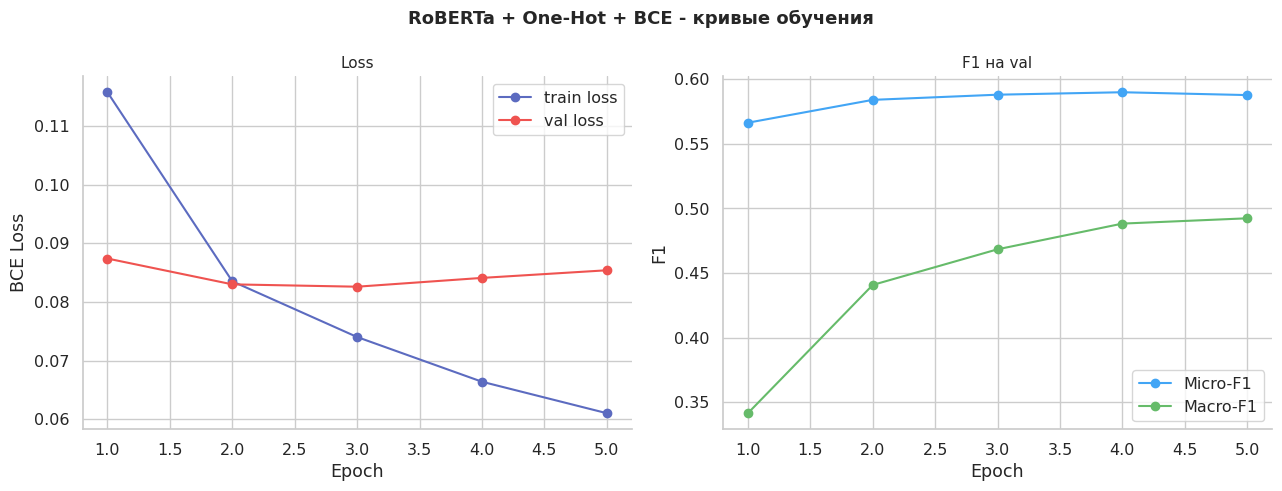

Сохранено: results/onehot_bce_training_curves.png


In [19]:
sns.set_theme(style='whitegrid', font_scale=1.05)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('RoBERTa + One-Hot + BCE - кривые обучения', fontsize=13, fontweight='bold')

epochs_range = range(1, CONFIG['num_epochs'] + 1)

ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'o-', color='#5C6BC0', label='train loss')
ax.plot(epochs_range, history['val_loss'], 'o-', color='#EF5350', label='val loss')
ax.set_title('Loss', fontsize=11)
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax2 = axes[1]
ax2.plot(epochs_range, history['val_micro_f1'], 'o-', color='#42A5F5', label='Micro-F1')
ax2.plot(epochs_range, history['val_macro_f1'], 'o-', color='#66BB6A', label='Macro-F1')
ax2.set_title('F1 на val', fontsize=11)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1')
ax2.legend()
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'onehot_bce_training_curves.png'), dpi=150)
plt.show()
print('Сохранено: results/onehot_bce_training_curves.png')

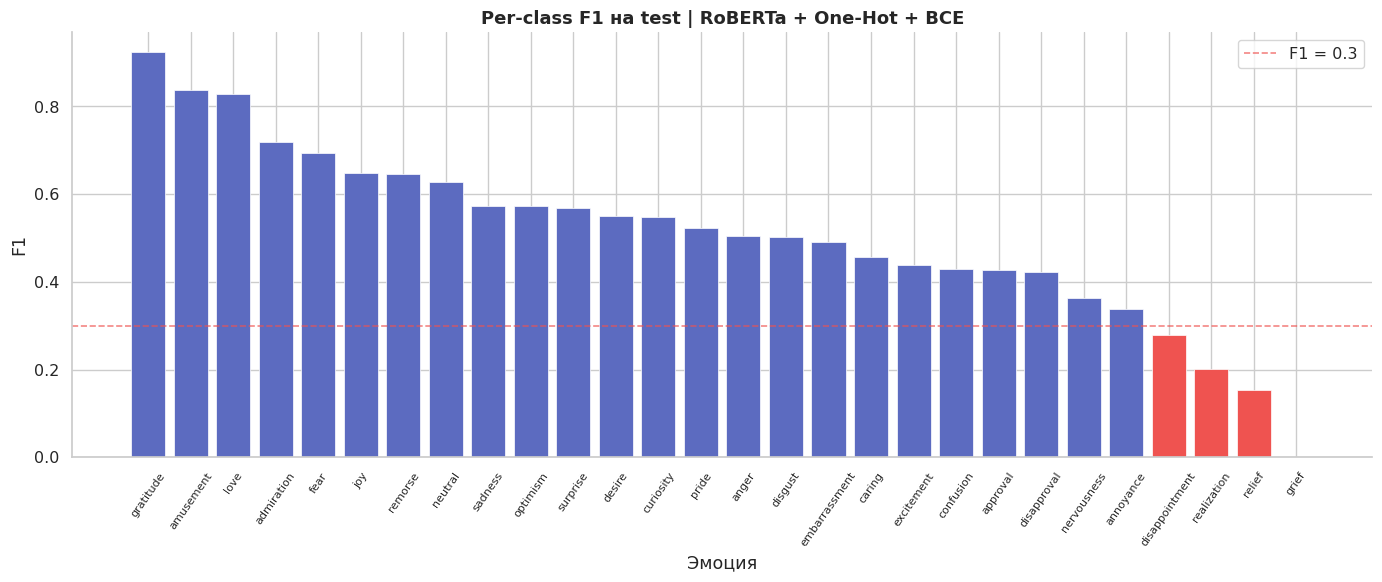

Сохранено: results/onehot_bce_per_class_f1.png


In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#EF5350' if f < 0.3 else '#5C6BC0' for f in df_per_class['f1']]
ax.bar(
    df_per_class['emotion'],
    df_per_class['f1'],
    color=colors,
    edgecolor='white',
    linewidth=0.5,
)

ax.axhline(0.3, color='#EF5350', linestyle='--', linewidth=1.2, alpha=0.7, label='F1 = 0.3')
ax.set_title('Per-class F1 на test | RoBERTa + One-Hot + BCE', fontsize=13, fontweight='bold')
ax.set_xlabel('Эмоция')
ax.set_ylabel('F1')
ax.tick_params(axis='x', rotation=55, labelsize=8)
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'onehot_bce_per_class_f1.png'), dpi=150)
plt.show()
print('Сохранено: results/onehot_bce_per_class_f1.png')

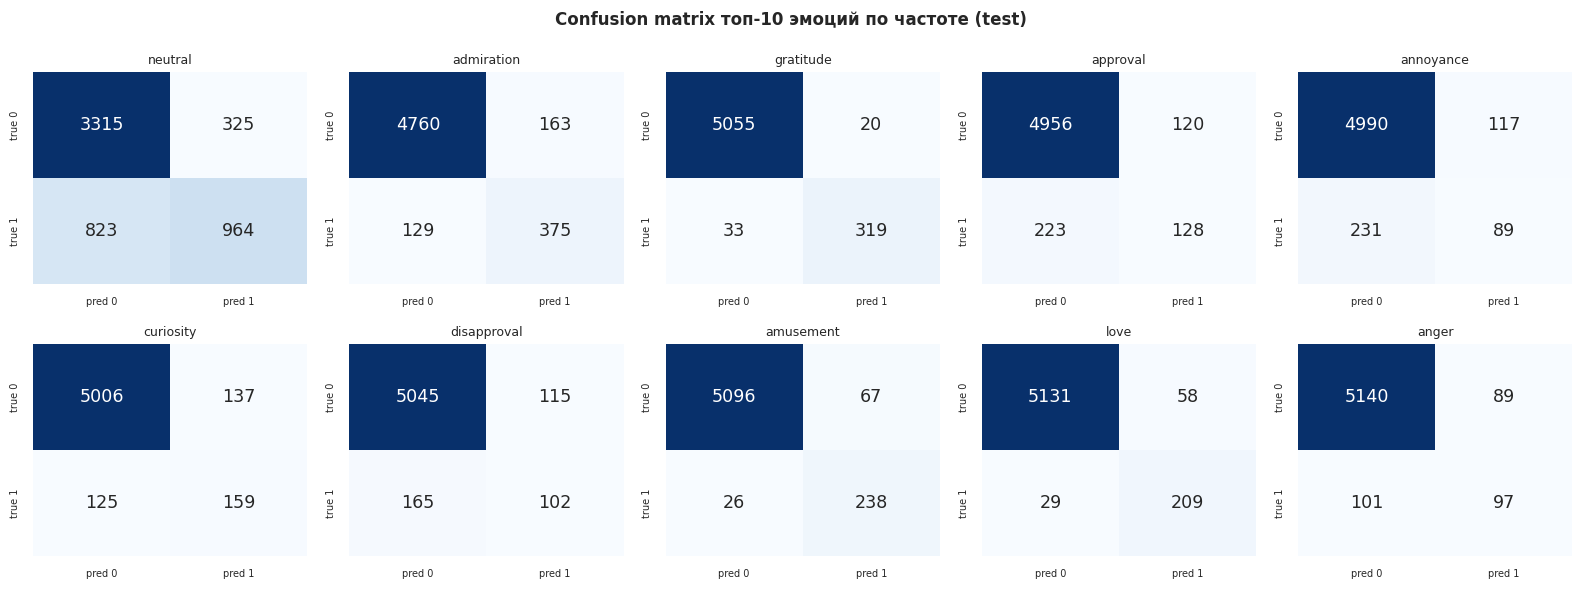

Сохранено: results/onehot_bce_confusion_top10.png


In [21]:
from sklearn.metrics import multilabel_confusion_matrix

top10_emotions = (
    df_per_class.sort_values('support', ascending=False)
    .head(10)['emotion'].tolist()
)
emotion_idx = [EMOTIONS.index(e) for e in top10_emotions]

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
fig.suptitle('Confusion matrix топ-10 эмоций по частоте (test)', fontsize=12, fontweight='bold')

mcm = multilabel_confusion_matrix(test_labels, binary_preds)

for ax, idx, emo in zip(axes.flat, emotion_idx, top10_emotions):
    cm = mcm[idx]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        ax=ax, cbar=False,
        xticklabels=['pred 0', 'pred 1'],
        yticklabels=['true 0', 'true 1'],
    )
    ax.set_title(emo, fontsize=9)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['results_dir'], 'onehot_bce_confusion_top10.png'), dpi=150)
plt.show()
print('Сохранено: results/onehot_bce_confusion_top10.png')

## Сохранение результатов

In [22]:
results = {
    'experiment': 'onehot_bce',
    'model': CONFIG['model_name'],
    'label_type': 'one-hot',
    'loss': 'BCEWithLogitsLoss',
    'config': CONFIG,
    'val_best_macro_f1': best_macro_f1,
    'test_metrics': test_metrics,
    'history': history,
}

results_path = os.path.join(CONFIG['results_dir'], 'onehot_bce_metrics.json')
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print(f'Сохранено: {results_path}')

Сохранено: results/onehot_bce_metrics.json


**Выводы:**

Итоговые метрики : Micro-F1 = 0.59, Macro-F1 = 0.50. Если смотреть на Per-class F1, то высокий скор у наиболее часто встречающихся эмоций, у редких скор маленький.

Еще плохо предсказывается neutral: 823 примера true 1 предсказаны как 0, но 325 примеров true 0 предсказаны как 1.